Beautiful fact:  If we take $W$ to be a random Gaussian matrix (namely such that each entry $w_{ij}$ is independent and $N(0,1)$)
then the QR factorization of $W$ (determined through a Gram-Schmidt process) produces a $Q$ which is uniformly distributed on $SO(n)$.

In [2]:
#Some Importing Some External Libraries

#Our MCMC sampliers
%run MCMC_Sampliers.ipynb

import warnings
warnings.filterwarnings('ignore')

#Plotting Libraries
import matplotlib.pyplot as plt
from numpy.linalg import norm
from numpy import dot, array, transpose, diag
import matplotlib.image as mpimg

#Fun Progress Bar
from tqdm.notebook import tqdm

In [3]:
#Utilities

#Code to generate a random orthogonal matrix (uniform from O(n)) using the QR factorization of a Guassian matrix.
def rndm_orth_matrix(n):

    #Generate a random n x n matrix with i.i.d. normal entries
    A = np.random.randn(n, n)
    
    #Perform the QR factorization
    Q, R = np.linalg.qr(A)    
    
    return Q

def Vec2Mat(vec, L, M):
    """
    Reshape a 1D vector of length N into an L x M matrix.
    Assumes N = L * M.

    Parameters
    ----------
    vec : array_like
        A 1D array/list of length N.
    L : int
        Number of rows in the resulting matrix.
    M : int
        Number of columns in the resulting matrix.

    Returns
    -------
    matrix : np.ndarray
        An L x M NumPy array containing the reshaped data.
    """
    # Convert to a NumPy array if not already
    vec_array = np.asarray(vec)

    # Reshape into LxM
    matrix = vec_array.reshape(L, M)
    return matrix

In [45]:
#Example 1: 2x2 Products

#Dimentions of Matricies 
M1dimw =2
M12dimhw =2
M2dimh =2

#Dimentions of Priors 
priorDimM1 = M1dimw*M12dimhw
priorDimM2 = M12dimhw*M2dimh
priorDim = priorDimM1 + priorDimM2

#Data and Precision

Zdata = np.array([[1,0],[0,1]])
#sqrtPrec = np.array([[1,0],[0,1]])
sig = 2


dataMisMatch = lambda X : Vec2Mat(X[:priorDimM1],M1dimw, M12dimhw) @ Vec2Mat(X[priorDimM1:priorDim],M12dimhw,M2dimh) -Zdata
nloglikelihood = lambda X: .5* sig**(-2) * (np.linalg.norm(dataMisMatch(X), ord='fro'))**2


#Specifying the prior

Q = random_orthogonal_matrix(priorDim)
EVals = np.diag([.2,2,1,4,2,1,.5,.3])

prCov = Q.T@EVals@Q

print(prCov)

[[ 0.98395979 -0.52841713 -0.11174789  0.21266328  0.23033877 -0.26073485
   0.53783488 -0.23131447]
 [-0.52841713  1.5737529  -0.39649301  0.09949525  0.39491458  0.42611452
  -0.87362847  0.39208335]
 [-0.11174789 -0.39649301  0.7656159  -0.47530287 -0.29905159 -0.40517888
   0.51838141 -0.30744555]
 [ 0.21266328  0.09949525 -0.47530287  1.48196248 -0.29331482  0.0811759
   0.38562     0.26585875]
 [ 0.23033877  0.39491458 -0.29905159 -0.29331482  1.74228768  0.79456558
  -0.32169397 -0.05970516]
 [-0.26073485  0.42611452 -0.40517888  0.0811759   0.79456558  1.56344067
  -0.67680442  0.38652578]
 [ 0.53783488 -0.87362847  0.51838141  0.38562    -0.32169397 -0.67680442
   2.11193406 -0.28534865]
 [-0.23131447  0.39208335 -0.30744555  0.26585875 -0.05970516  0.38652578
  -0.28534865  0.77704653]]


  
MpCN Run
Total samples generated: 40000
rho Value: 0.6
number of proposal p: 100
  


  0%|          | 0/40 [00:00<?, ?it/s]

Number of failed runs: 0
Percentage of Failure: 0.0
Number of MpCN Samples Now Available: 39999


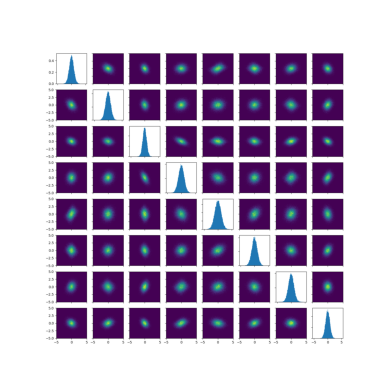

In [46]:
#Generate Data Using MpCN

NumRuns =  40 #of total runs
NumSamps = 1000 #samples per run


#Specifying File Location to Save Data 

#subdirectory from current location of python notebook (this should be created manually)
FileNmBase= "Data/Prod_Inversion_Toy/"

paraStr = "Example_1_1"
histFileNm = FileNmBase + "HIST" + paraStr + ".png"
csvFileNm = FileNmBase + "DATA" + paraStr + ".csv"


rho = .6
pSmp = 100

print("  ")
print("MpCN Run")
print("Total samples generated: " + str(NumRuns*NumSamps))

print("rho Value: " + str(rho))
print("Number of proposal p: " + str(pSmp))
print("  ")


badtryNm = 0


#Make mpCN Run Saving to .csv ensuring NAN errors do not stop the process

q0 = np.random.normal(0,1,priorDim)
for curRnInx in tqdm(range(0,NumRuns)):
    try:
        cursamps = MpCN(q0,priorDim,prCov,rho,nloglikelihood,pSmp,NumSamps +1)
        q0 = cursamps.pop()
        writeCSV(csvFileNm,cursamps)
    except OverflowError:
        badtryNm = badtryNm +1

print("Number of failed runs: " + str(badtryNm))
print("Percentage of Failure: " + str(badtryNm/NumRuns))

#Make Histogram

mpCNsampTr = readCSV(csvFileNm)
samLenmpCN = len(mpCNsampTr)
print("Number of MpCN Samples Now Available: " + str(samLenmpCN))

#Dimensions For Histogram Plot
R = 5
dr = .1

makeHistGrid(R, dr, mpCNsampTr, priorDim,histFileNm, True)

img = mpimg.imread(histFileNm)
plt.imshow(img)
plt.axis('off')  # Turn off the axes
plt.show()

In [62]:
#Example 2: Dot Products Rotated


#Dimentions of vectors
vDim = 4
paramDim = 2*vDim

#Data and Precision

Zdata = 9
sig = .2

nloglikelihood = lambda X: .5* sig**(-2) * (np.dot(X[:vDim], X[vDim:paramDim]) - Zdata)**2


#Specifying the prior

#Q = random_orthogonal_matrix(paramDim)
#EVals = np.diag([.2,.1,1,6,2,1,.5,.3])

#prCov = Q.T@EVals@Q

#print(prCov)

# Q was produced as above.  The random value used in Example 2.3 is as below.

Q = np.array([[ 1.12563505  0.08925323  1.24673884  0.60644824 -0.38105084 -0.39952002
   0.36223847 -0.48696264]
 [ 0.08925323  0.47367041  0.1127561  -0.04599354 -0.07463478 -0.23696268
  -0.25081426 -0.14941305]
 [ 1.24673884  0.1127561   3.24051008  1.53738654 -1.26656789 -0.23414781
   0.4827102  -1.464844  ]
 [ 0.60644824 -0.04599354  1.53738654  1.46487699 -0.9315473  -0.38368664
   0.23214179 -0.23248516]
 [-0.38105084 -0.07463478 -1.26656789 -0.9315473   1.3326886   0.18683977
  -0.19062313  0.43766708]
 [-0.39952002 -0.23696268 -0.23414781 -0.38368664  0.18683977  0.78825401
   0.07725333 -0.5107983 ]
 [ 0.36223847 -0.25081426  0.4827102   0.23214179 -0.19062313  0.07725333
   0.78299885 -0.1140427 ]
 [-0.48696264 -0.14941305 -1.464844   -0.23248516  0.43766708 -0.5107983
  -0.1140427   1.89136601]])

[[ 1.12563505  0.08925323  1.24673884  0.60644824 -0.38105084 -0.39952002
   0.36223847 -0.48696264]
 [ 0.08925323  0.47367041  0.1127561  -0.04599354 -0.07463478 -0.23696268
  -0.25081426 -0.14941305]
 [ 1.24673884  0.1127561   3.24051008  1.53738654 -1.26656789 -0.23414781
   0.4827102  -1.464844  ]
 [ 0.60644824 -0.04599354  1.53738654  1.46487699 -0.9315473  -0.38368664
   0.23214179 -0.23248516]
 [-0.38105084 -0.07463478 -1.26656789 -0.9315473   1.3326886   0.18683977
  -0.19062313  0.43766708]
 [-0.39952002 -0.23696268 -0.23414781 -0.38368664  0.18683977  0.78825401
   0.07725333 -0.5107983 ]
 [ 0.36223847 -0.25081426  0.4827102   0.23214179 -0.19062313  0.07725333
   0.78299885 -0.1140427 ]
 [-0.48696264 -0.14941305 -1.464844   -0.23248516  0.43766708 -0.5107983
  -0.1140427   1.89136601]]


  
MpCN Run
Total samples generated: 400000
rho Value: 0.6
Number of proposal p: 100
  


  0%|          | 0/400 [00:00<?, ?it/s]

Number of failed runs: 0
Percentage of Failure: 0.0
Number of MpCN Samples Now Available: 439999


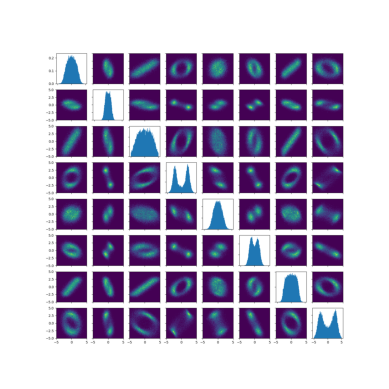

In [64]:
#Generate Data Using MpCN

NumRuns =  400 #of total runs
NumSamps = 1000 #samples per run


#Specifying File Location to Save Data 

#subdirectory from current location of python notebook (this should be created manually)
FileNmBase= "Data/Prod_Inversion_Toy/"

paraStr = "Example_2_3"
histFileNm = FileNmBase + "HIST" + paraStr + ".png"
csvFileNm = FileNmBase + "DATA" + paraStr + ".csv"


rho = .6
pSmp = 100

print("  ")
print("MpCN Run")
print("Total samples generated: " + str(NumRuns*NumSamps))

print("rho Value: " + str(rho))
print("Number of proposal p: " + str(pSmp))
print("  ")


badtryNm = 0


#Make mpCN Run Saving to .csv ensuring NAN errors do not stop the process

q0 = np.random.normal(0,1,paramDim)
for curRnInx in tqdm(range(0,NumRuns)):
    try:
        cursamps = MpCN(q0,paramDim,prCov,rho,nloglikelihood,pSmp,NumSamps +1)
        q0 = cursamps.pop()
        writeCSV(csvFileNm,cursamps)
    except OverflowError:
        badtryNm = badtryNm +1

print("Number of failed runs: " + str(badtryNm))
print("Percentage of Failure: " + str(badtryNm/NumRuns))

#Make Histogram

mpCNsampTr = readCSV(csvFileNm)
samLenmpCN = len(mpCNsampTr)
print("Number of MpCN Samples Now Available: " + str(samLenmpCN))

#Dimensions For Histogram Plot
R = 5
dr = .1

makeHistGrid(R, dr, mpCNsampTr, priorDim,histFileNm, True)

img = mpimg.imread(histFileNm)
plt.imshow(img)
plt.axis('off')  # Turn off the axes
plt.show()

In [6]:
#Example 3: Dot Products without rotation


#Dimentions of vectors
vDim = 4
paramDim = 2*vDim

#Data and Precision

Zdata = 9
sig = .2

nloglikelihood = lambda X: .5* sig**(-2) * (np.dot(X[:vDim], X[vDim:paramDim]) - Zdata)**2


#Specifying the prior


prCov = np.diag([.2,.1,1,6,2,1,.5,.3])

  
MpCN Run
Total samples generated: 10000
rho Value: 0.6
Number of proposal p: 100
  


  0%|          | 0/10 [00:00<?, ?it/s]

Number of failed runs: 0
Percentage of Failure: 0.0
Number of MpCN Samples Now Available: 419999


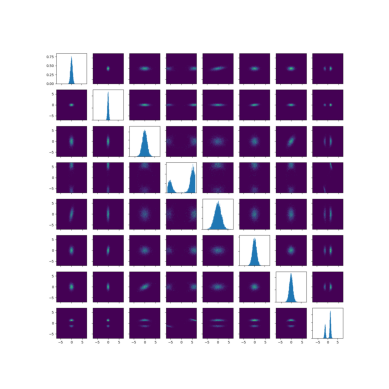

In [9]:
#Generate Data Using MpCN

NumRuns =  10 #of total runs
NumSamps = 1000 #samples per run


#Specifying File Location to Save Data 

#subdirectory from current location of python notebook (this should be created manually)
FileNmBase= "Data/Prod_Inversion_Toy/"

paraStr = "Example_3_1"
histFileNm = FileNmBase + "HIST" + paraStr + ".png"
csvFileNm = FileNmBase + "DATA" + paraStr + ".csv"


rho = .6
pSmp = 100

print("  ")
print("MpCN Run")
print("Total samples generated: " + str(NumRuns*NumSamps))

print("rho Value: " + str(rho))
print("Number of proposal p: " + str(pSmp))
print("  ")


badtryNm = 0


#Make mpCN Run Saving to .csv ensuring NAN errors do not stop the process

q0 = np.random.normal(0,1,paramDim)
for curRnInx in tqdm(range(0,NumRuns)):
    try:
        cursamps = MpCN(q0,paramDim,prCov,rho,nloglikelihood,pSmp,NumSamps +1)
        q0 = cursamps.pop()
        writeCSV(csvFileNm,cursamps)
    except OverflowError:
        badtryNm = badtryNm +1

print("Number of failed runs: " + str(badtryNm))
print("Percentage of Failure: " + str(badtryNm/NumRuns))

#Make Histogram

mpCNsampTr = readCSV(csvFileNm)
samLenmpCN = len(mpCNsampTr)
print("Number of MpCN Samples Now Available: " + str(samLenmpCN))

#Dimensions For Histogram Plot
R = 7
dr = .05

makeHistGrid(R, dr, mpCNsampTr, paramDim,histFileNm, True)

img = mpimg.imread(histFileNm)
plt.imshow(img)
plt.axis('off')  # Turn off the axes
plt.show()